In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root
from scipy.special import sici
from classy import Class
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

In [2]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
k_out = [0.01,0.1, 0.5]
common_settings = {
'omega_b':0.0223828,
'h':h,
'z_reio':7.6711,
'YHe':0.25,
'perturbations_verbose':1,
'background_verbose':3,
'output':'mTk,dTk, vTk, mPk',
'k_output_values':str(k_out).strip('[]'),
'P_k_max_h/Mpc':10,
'z_max_pk':20,
'format':'class',
}

In [3]:

Mnu=3.
nuCDM = Class()
nuCDM.set(common_settings)
nuCDM.set({
    'N_ur': 3.046,
    # 'N_ncdm':1,
    # 'm_ncdm':Mnu,
    'N_ncdm':3,
    'm_ncdm':f'{Mnu/3:.1g},{Mnu/3:.1g},{Mnu/3:.1g}',
    'ncdm_fluid_approximation':3,
    'l_max_ncdm': 17,
    # 'tol_ncdm': 1.e-6,
    'tol_ncdm_bg': 1.e-7,
})

nuCDM.compute()

Running CLASS version v3.2.5
Computing background
 -> non-cold dark matter species with i=1 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314332e+01 eV)
 -> ncdm species i=1 sampled with 16 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=2 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314332e+01 eV)
 -> ncdm species i=2 sampled with 16 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=3 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314332e+01 eV)
 -> ncdm species i=3 sampled with 16 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
Chose ndf15 as generic_evolver
 -> age = 12.993146 Gyr
 -> conformal age = 13032.487705 Mpc
 -> N_eff = 6.08561 (summed over all

In [4]:
nubck =nuCDM.get_background()
w_ncdm_z = interp1d(nubck['z'], nubck['(.)p_ncdm[0]']/nubck['(.)rho_ncdm[0]'])
kidx=0
nupert = nuCDM.get_perturbations()['scalar'][kidx]

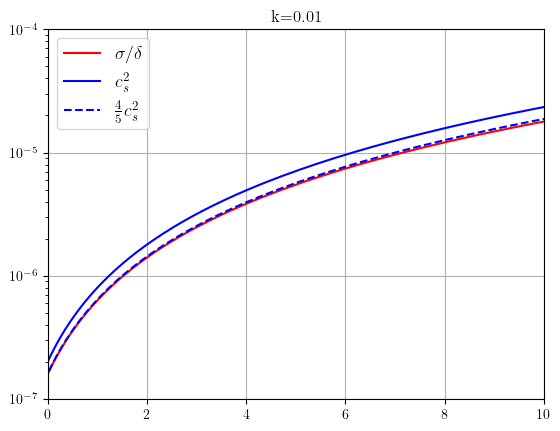

In [5]:
apt = nupert['a']
d_nu = nupert['delta_ncdm[0]']
shear_nu = nupert['shear_ncdm[0]']
cs2_nu = nupert['cs2_ncdm[0]']
zpt = 1/apt-1 
cs2_nu_z = interp1d(zpt,nupert['cs2_ncdm[0]'], fill_value='extrapolate')

# a_bck = 1/(nubck['z']+1) # read redshift
# drho_nu_da = np.gradient(nubck['(.)rho_ncdm[0]'], a_bck)
# dp_nu_da = np.gradient(nubck['(.)p_ncdm[0]'], a_bck)
# cFS2_nu=interp1d(nubck['z'],dp_nu_da/drho_nu_da)

plt.figure()

# plt.plot(zpt, w_ncdm_z(zpt), 'b', label=r'$w$')

plt.plot(zpt, np.abs(shear_nu/d_nu), 'r', label=r'$\sigma/\delta$')

plt.plot(zpt, cs2_nu, 'b', label=r'$c_s^2$')

plt.plot(zpt, 4/5*cs2_nu/(1+w_ncdm_z(zpt)),'b--', label=r'$\frac{4}{5} c_s^2$')

plt.xlim([0,10])
# plt.ylim([0,2])

plt.ylim([1.e-7,1.e-4])
plt.title(f'k={k_out[kidx]}')
plt.legend(fontsize=13)
plt.yscale('log')
plt.grid()
plt.show()

0.5258800757715628


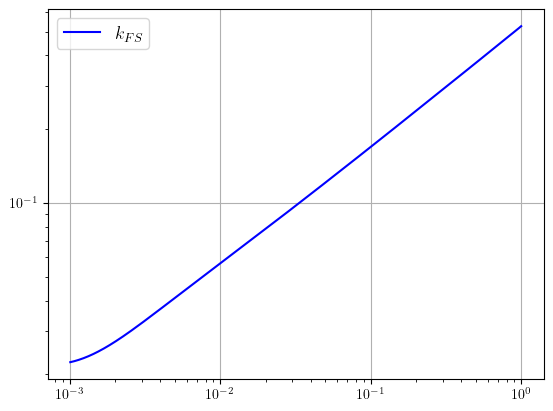

In [6]:
Omega_m=(nubck['(.)rho_cdm']+nubck['(.)rho_b']+nubck['(.)rho_ncdm[0]'])/nubck['(.)rho_crit']
Ha=nubck['H [1/Mpc]']/(1.+nubck['z'])
a_bck = 1/(nubck['z']+1) # read redshift
amask = a_bck>1.e-3
k_FS_nu=np.sqrt(3/2*Omega_m)*Ha/h/(np.sqrt(cs2_nu_z(nubck['z'])))
plt.figure()

plt.loglog(a_bck[amask], k_FS_nu[amask], 'b', label=r'$k_{FS}$')
print(k_FS_nu[-1])
plt.legend(fontsize=13)
plt.grid()
plt.show()

---
as a function of $k$

In [16]:
kvals = np.logspace(-2,0.3,15)
nuCDM.set({'k_output_values':str(kvals.tolist()).strip('[]')})
nuCDM.compute()

Running CLASS version v3.2.5
Computing background
 -> non-cold dark matter species with i=1 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314332e+01 eV)
 -> ncdm species i=1 sampled with 16 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=2 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314332e+01 eV)
 -> ncdm species i=2 sampled with 16 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=3 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314332e+01 eV)
 -> ncdm species i=3 sampled with 16 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
Chose ndf15 as generic_evolver
 -> age = 12.993146 Gyr
 -> conformal age = 13032.487705 Mpc
 -> N_eff = 6.08561 (summed over all

/tmp/ipykernel_1010584/4079664673.py:8: RuntimeWarning: invalid value encountered in divide
  plt.plot(kvals/h, d_nu_k/d_cdm_k, 'k', label=r'$\delta_\chi/\delta_c$')
/tmp/ipykernel_1010584/4079664673.py:10: RuntimeWarning: invalid value encountered in divide
  R_k_mio = (shear_nu_k+(4/5*cs2_nu_k/(1+w_ncdm_z(0.01))*d_nu_k))/(9/5*cs2_nu_k*d_nu_k)


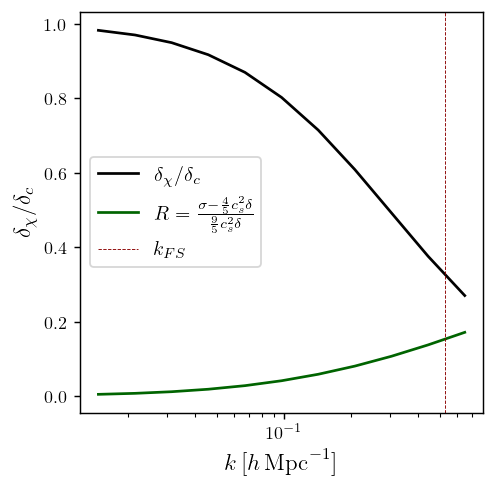

In [41]:
shear_nu_k = np.array([nuCDM.get_perturbations()['scalar'][i]['shear_ncdm[0]'][-1] for i in range(len(kvals))])
cs2_nu_k = np.array([nuCDM.get_perturbations()['scalar'][i]['cs2_ncdm[0]'][-1] for i in range(len(kvals))])
d_nu_k = np.array([nuCDM.get_perturbations()['scalar'][i]['delta_ncdm[0]'][-1] for i in range(len(kvals))])
d_cdm_k = np.array([nuCDM.get_perturbations()['scalar'][i]['delta_cdm'][-1] for i in range(len(kvals))])

plt.figure(figsize=(4,4), dpi=130)

plt.plot(kvals/h, d_nu_k/d_cdm_k, 'k', label=r'$\delta_\chi/\delta_c$')

R_k_mio = (shear_nu_k+(4/5*cs2_nu_k/(1+w_ncdm_z(0.01))*d_nu_k))/(9/5*cs2_nu_k*d_nu_k)

plt.plot(kvals/h, R_k_mio, 'darkgreen', linewidth=1.5,label=r'$R= \frac{ \sigma- \frac{4}{5}c_s^2 \delta}{\frac{9}{5}c_s^2 \delta}$')

plt.axvline(0.526, color='darkred', linestyle='--', linewidth=0.5, label=r'$k_{FS}$')

# plt.plot(kvals, cs2_nu_k)
plt.xscale('log')
plt.xlabel(r'$k\, [h\, \mathrm{Mpc}^{-1}]$', fontsize=13)
plt.ylabel(r'$\delta_{\chi}/\delta_c$', fontsize=13)

plt.legend(fontsize=11)

plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/chi_sigma.pdf',bbox_inches='tight')

plt.show()

----
check the best definition of cs2 that enters in kJ

In [ ]:
from scipy.integrate import odeint

fx = nuCDM.Omega_nu/nuCDM.Omega_m()
def lin_system(w,t):
    dc,Tc,dx,Tx = w
    ddcdt = Tc
    dTcdt = -0.5*Tc+1.5*(1-fx)*dc+1.5*fx*dx
    ddxdt = Tx
    dTxdt = -0.5*Tx+1.5*(1-fx)*dc+1.5*(fx-np.exp(-t))*dx
    return [ddcdt, dTcdt,ddxdt, dTxdt]
tlin =np.linspace(-10,10, 510)
w0 = [1,1-3/5*fx,0.,0.]
linsol = odeint(lin_system, w0, tlin)
g_full = interp1d(tlin,linsol[:,2]/linsol[:, 0], bounds_error=False, fill_value=(0,1))
def g_an(t):
    return  1 + 6 * np.exp(-t) * np.cos(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[1] - 3 * np.exp(-t) * np.pi * np.sin(np.sqrt(6) * np.exp(-t / 2)) + 6 * np.exp(-t) * np.sin(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[0]

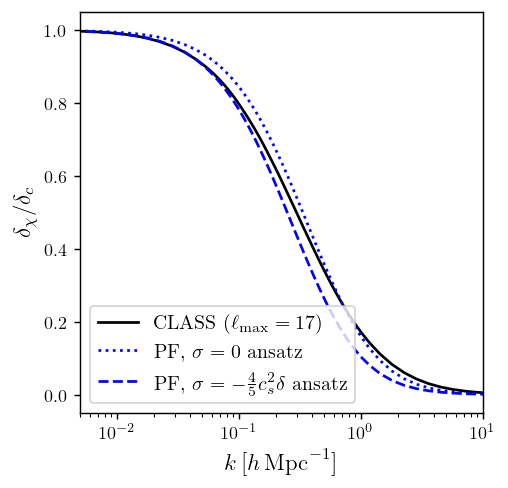

In [63]:
dnu_dc_k = np.array([nuCDM.get_transfer(z=0)['d_ncdm[0]']/nuCDM.get_transfer(z=0)['d_cdm']])[0]
kr = nuCDM.get_transfer(z=0)['k (h/Mpc)']

k_FS0=np.sqrt(3/2*nuCDM.Omega0_m())*(nubck['H [1/Mpc]'][-1]/nuCDM.h())/(np.sqrt(cs2_nu_z(0.)))

plt.figure(figsize=(4,4), dpi=130)

plt.plot(kr, dnu_dc_k, 'k', label='CLASS $(\ell_{\mathrm{max}}=17)$')
plt.plot(kr, g_full(-2*np.log(kr/k_FS0)), 'b:', label = r'PF, $\sigma = 0$ ansatz')
plt.plot(kr, g_full(-2*np.log(kr/(np.sqrt(5/9)*k_FS0))), 'b--', label = r'PF, $\sigma = -\frac{4}{5}c_s^2\delta$ ansatz')

plt.xlim([5.e-3,10])
plt.xscale('log')
plt.xlabel(r'$k\, [h\, \mathrm{Mpc}^{-1}]$', fontsize=13)
plt.ylabel(r'$\delta_{\chi}/\delta_c$', fontsize=13)

plt.legend(loc='lower left', fontsize=11)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/chi_vs_PF.pdf',bbox_inches='tight')

plt.show()


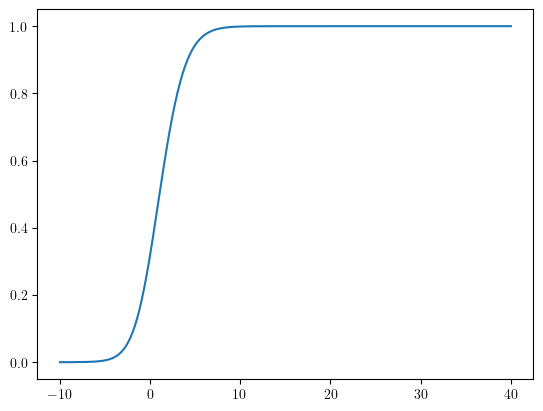